
# 04 - Improved Training (BCE + KL Annealing)

This notebook trains an improved Beta-VAE using:
- reconstruction loss: BCE
- KL schedule: linear annealing from `0` to `target_beta`

By default, it initializes from the baseline checkpoint if available.


In [1]:
import os
import warnings

# Silence Python-level warnings in notebook output.
warnings.filterwarnings('ignore')

# Reduce noisy runtime warnings from OpenMP/MKL in some environments.
os.environ['KMP_WARNINGS'] = '0'
os.environ['MKL_VERBOSE'] = '0'

import warnings
warnings.filterwarnings("ignore")

In [2]:

from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / 'data').exists() or (cwd / 'BayesML_Final_Project.ipynb').exists():
        return cwd
    if (cwd / '..' / 'data').resolve().exists() or (cwd / '..' / 'BayesML_Final_Project.ipynb').resolve().exists():
        return (cwd / '..').resolve()
    return cwd


PROJECT_ROOT = resolve_project_root()
PROJECT_ROOT


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


PosixPath('/Users/hjjh/Desktop/ML Project/Sneaker-Design-VAE')

## Training Configuration

In [3]:

PROCESSED_DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
CHECKPOINT_DIR = ARTIFACTS_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_CHECKPOINT_PATH = CHECKPOINT_DIR / 'beta_vae_baseline.pt'
IMPROVED_CHECKPOINT_PATH = CHECKPOINT_DIR / 'beta_vae_improved.pt'

BATCH_SIZE = 128
NUM_WORKERS = 4
LATENT_DIM = 16
LEARNING_RATE = 1e-3
EPOCHS = 30
TARGET_BETA = 2.0
ANNEAL_EPOCHS = 10
SEED = 42

if not PROCESSED_DATA_DIR.exists():
    raise FileNotFoundError(
        f'Processed dataset not found at {PROCESSED_DATA_DIR}. '
        'Run 01_data_preprocessing.ipynb first.'
    )

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Processed data: {PROCESSED_DATA_DIR}')
print(f'Baseline checkpoint: {BASELINE_CHECKPOINT_PATH}')
print(f'Improved checkpoint output: {IMPROVED_CHECKPOINT_PATH}')


Processed data: /Users/hjjh/Desktop/ML Project/Sneaker-Design-VAE/data
Baseline checkpoint: /Users/hjjh/Desktop/ML Project/Sneaker-Design-VAE/artifacts/checkpoints/beta_vae_baseline.pt
Improved checkpoint output: /Users/hjjh/Desktop/ML Project/Sneaker-Design-VAE/artifacts/checkpoints/beta_vae_improved.pt


## DataLoader

In [4]:

transform = transforms.Compose([
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(root=PROCESSED_DATA_DIR, transform=transform)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

print(f'Dataset size: {len(dataset)}')
print(f'Batches per epoch: {len(dataloader)}')


Dataset size: 12856
Batches per epoch: 101


## Model Definition

In [5]:

class BetaVAE(nn.Module):
    def __init__(self, latent_dim: int = 16):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
        )

        self.fc_mu = nn.Linear(4096, latent_dim)
        self.fc_log_var = nn.Linear(4096, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 4096)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def reparameterize(self, mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x: torch.Tensor):
        encoded = self.encoder(x)
        flat = torch.flatten(encoded, start_dim=1)
        mu = self.fc_mu(flat)
        log_var = self.fc_log_var(flat)
        z = self.reparameterize(mu, log_var)

        decoded = self.fc_decode(z)
        decoded = decoded.view(-1, 256, 4, 4)
        reconstruction = self.decoder(decoded)
        return reconstruction, mu, log_var


## Improved Loss and KL Annealing

In [6]:

def beta_vae_loss_bce(
    reconstruction: torch.Tensor,
    target: torch.Tensor,
    mu: torch.Tensor,
    log_var: torch.Tensor,
    current_beta: float,
):
    # Beta-VAE loss with BCE reconstruction and dynamic beta.
    recon_loss = F.binary_cross_entropy(reconstruction, target, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    total_loss = recon_loss + current_beta * kl_loss
    return total_loss, recon_loss, kl_loss


def linear_beta_schedule(epoch: int, anneal_epochs: int, target_beta: float) -> float:
    # Increase beta linearly from 0 to target_beta during warmup epochs.
    if epoch >= anneal_epochs:
        return target_beta
    return target_beta * (epoch / anneal_epochs)


def train_improved(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: optim.Optimizer,
    device: torch.device,
    epochs: int,
    target_beta: float,
    anneal_epochs: int,
):
    history = {
        'total_loss': [],
        'recon_loss': [],
        'kl_loss': [],
        'beta': [],
    }

    for epoch in range(epochs):
        model.train()
        running_total = 0.0
        running_recon = 0.0
        running_kl = 0.0

        current_beta = linear_beta_schedule(epoch, anneal_epochs, target_beta)
        history['beta'].append(current_beta)

        for batch, _ in dataloader:
            batch = batch.to(device)
            optimizer.zero_grad()

            reconstruction, mu, log_var = model(batch)
            total_loss, recon_loss, kl_loss = beta_vae_loss_bce(
                reconstruction,
                batch,
                mu,
                log_var,
                current_beta,
            )

            total_loss.backward()
            optimizer.step()

            running_total += total_loss.item()
            running_recon += recon_loss.item()
            running_kl += kl_loss.item()

        dataset_size = len(dataloader.dataset)
        avg_total = running_total / dataset_size
        avg_recon = running_recon / dataset_size
        avg_kl = running_kl / dataset_size

        history['total_loss'].append(avg_total)
        history['recon_loss'].append(avg_recon)
        history['kl_loss'].append(avg_kl)

        print(
            f'Epoch {epoch + 1:02d}/{epochs} | '
            f'Beta: {current_beta:.3f} | '
            f'Total: {avg_total:.4f} | Recon: {avg_recon:.4f} | KL: {avg_kl:.4f}'
        )

    return history


## Initialize Model and Optionally Load Baseline Weights

In [7]:

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

model = BetaVAE(latent_dim=LATENT_DIM).to(device)

if BASELINE_CHECKPOINT_PATH.exists():
    ckpt = torch.load(BASELINE_CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded baseline weights from {BASELINE_CHECKPOINT_PATH}')
else:
    print('Baseline checkpoint not found. Training starts from random initialization.')

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f'Using device: {device}')


Loaded baseline weights from /Users/hjjh/Desktop/ML Project/Sneaker-Design-VAE/artifacts/checkpoints/beta_vae_baseline.pt
Using device: mps


## Train Improved Model

In [8]:

history = train_improved(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    target_beta=TARGET_BETA,
    anneal_epochs=ANNEAL_EPOCHS,
)


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## Plot Loss and Beta Schedule

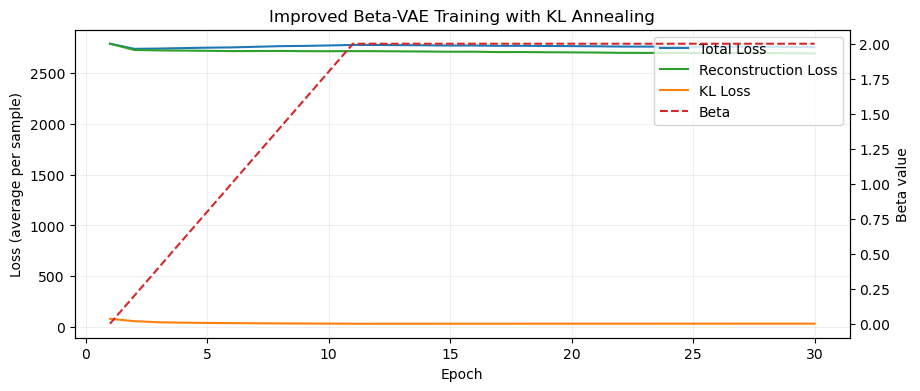

In [9]:

epochs_range = np.arange(1, EPOCHS + 1)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.plot(epochs_range, history['total_loss'], color='tab:blue', label='Total Loss')
ax1.plot(epochs_range, history['recon_loss'], color='tab:green', label='Reconstruction Loss')
ax1.plot(epochs_range, history['kl_loss'], color='tab:orange', label='KL Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (average per sample)')
ax1.grid(True, alpha=0.2)

ax2.plot(epochs_range, history['beta'], color='tab:red', linestyle='--', label='Beta')
ax2.set_ylabel('Beta value')

line_handles, line_labels = ax1.get_legend_handles_labels()
beta_handles, beta_labels = ax2.get_legend_handles_labels()
ax1.legend(line_handles + beta_handles, line_labels + beta_labels, loc='upper right')

plt.title('Improved Beta-VAE Training with KL Annealing')
plt.show()


## Save Improved Checkpoint

In [10]:

torch.save(
    {
        'latent_dim': LATENT_DIM,
        'model_state_dict': model.state_dict(),
        'history': history,
        'target_beta': TARGET_BETA,
        'anneal_epochs': ANNEAL_EPOCHS,
        'epochs': EPOCHS,
        'loss_type': 'bce',
        'classes': dataset.classes,
    },
    IMPROVED_CHECKPOINT_PATH,
)

print(f'Improved checkpoint saved to: {IMPROVED_CHECKPOINT_PATH}')


Improved checkpoint saved to: /Users/hjjh/Desktop/ML Project/Sneaker-Design-VAE/artifacts/checkpoints/beta_vae_improved.pt
